In [1]:
import igl
import numpy as np
from src.ms_new import MorseSmale
from src import vis
from src import pathtools
from src import triangletools

import networkx as nx
import pandas as pd

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pyvista as pv

from src import shapes

In [3]:
import pickle as pkl

with open('data/hard-goat.pkl', 'rb') as file:
#with open('data/hard-goat-cut.pkl', 'rb') as file:
    vertices, faces, values = pkl.load(file)

print(f'vertices.shape = {vertices.shape}')
print(f'faces.shape = {faces.shape}')
print(f'values.shape = {values.shape}')

vertices.shape = (2150, 3)
faces.shape = (3998, 3)
values.shape = (2150,)


In [ ]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, scalars=values, cmap="viridis", smooth_shading=False, show_edges=True, opacity=1.0)
pl.show()

Widget(value='<iframe src="http://localhost:38747/index.html?ui=P_0x7acec08f60f0_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


In [5]:
ms = MorseSmale(faces=faces, values=values, vertices=vertices)

In [6]:
(ms.local_maxima, ms.local_minima, ms.saddles)

(array([   0,  224,  534, 1130, 1694, 2107, 2120, 2137]),
 array([  80,  196,  523, 1058, 1176, 1199, 1778, 1897, 2089]),
 array([  54,   71,  158,  449,  489,  525,  931,  977, 1003, 1148, 1270,
        1350, 1451, 1564, 1921, 2013, 2129]))

In [7]:
print(f'local_maxima: {len(ms.local_maxima)}')
print(f'local_minima: {len(ms.local_minima)}')
print(f'saddles: {len(ms.saddles)}')

local_maxima: 8
local_minima: 9
saddles: 17


In [8]:
ms.saddles

array([  54,   71,  158,  449,  489,  525,  931,  977, 1003, 1148, 1270,
       1350, 1451, 1564, 1921, 2013, 2129])

In [9]:
print(f'          ms.local_maxima  = {ms.local_maxima}\nms.values[ms.local_maxima] = {ms.values[ms.local_maxima]}')
print(f'          ms.local_minima  = {ms.local_minima}\nms.values[ms.local_minima] = {ms.values[ms.local_minima]}')
print(f'          ms.saddles  = {ms.saddles}\nms.values[ms.saddles] = {ms.values[ms.saddles]}')


          ms.local_maxima  = [   0  224  534 1130 1694 2107 2120 2137]
ms.values[ms.local_maxima] = [ 1.          0.97929624  0.99043239  0.99876966 -0.2022893   1.
  0.99996618  0.9999514 ]
          ms.local_minima  = [  80  196  523 1058 1176 1199 1778 1897 2089]
ms.values[ms.local_minima] = [-0.98801457 -1.00656034 -1.00524038 -1.00660782 -1.00590338 -1.00164579
 -1.00636823 -1.52792293 -0.69119076]
          ms.saddles  = [  54   71  158  449  489  525  931  977 1003 1148 1270 1350 1451 1564
 1921 2013 2129]
ms.values[ms.saddles] = [-0.9813481   0.59429978 -0.99989386 -0.27504044 -0.99857391  0.36964455
 -0.87721937 -0.68711423 -0.25429362 -0.99497931 -0.94130074 -0.45005335
 -0.20907633  0.87358264 -0.99923691 -0.99970176 -0.99994135]


In [10]:
paths = ms.get_paths(how='increasing-decreasing')
#paths = ms.get_paths(how='decreasing-increasing')

Searching paths: 62it [00:48,  1.27it/s, Returned directions=set()]                        


In [11]:
pl = pv.Plotter(window_size=(600, 600))


pl.add_mesh(mesh, scalars=values, cmap="viridis", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_points(ms.vertices[ms.local_minima], color="lime", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.local_maxima], color="red", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.saddles], color="orchid", point_size=12, render_points_as_spheres=True)

for path in ms.get_paths():
    n_sides = len(pathtools.get_path_sides(path, faces))
    path_color = {1: 'orangered', 2: 'white'}[n_sides]

    path_vertices = ms.vertices[path]

    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(
        line,
        color=path_color,
        line_width=6,
        render_lines_as_tubes=True,
    )


pl.show()

Widget(value='<iframe src="http://localhost:38747/index.html?ui=P_0x7ace961543e0_1&reconnect=auto" class="pyvi…

In [12]:
pl = pv.Plotter(window_size=(600, 600))

pl.add_mesh(mesh, scalars=values, cmap="viridis", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_points(ms.vertices[ms.local_minima], color="lime", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.local_maxima], color="red", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[ms.saddles], color="orchid", point_size=12, render_points_as_spheres=True)

for path_vertices in tqdm(ms.iterate_paths_close_geodesics(), total=ms.n_paths):
    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(
        line,
        color="white",
        line_width=6,
        render_lines_as_tubes=True,
    )


pl.show()

  0%|          | 0/61 [00:00<?, ?it/s]

Widget(value='<iframe src="http://localhost:38747/index.html?ui=P_0x7ace96157590_2&reconnect=auto" class="pyvi…

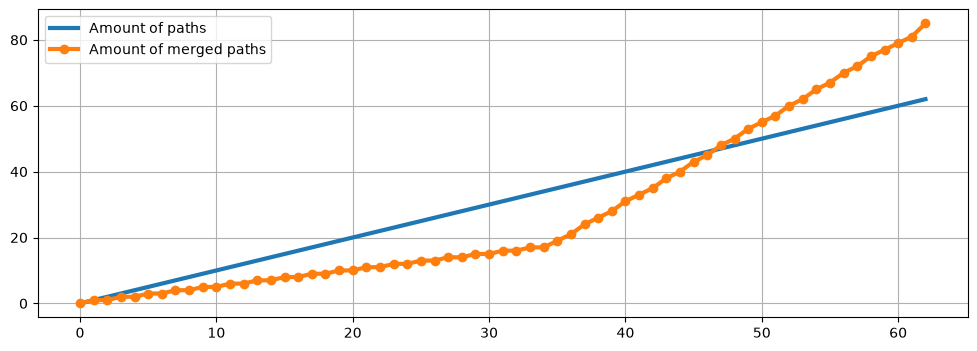

In [13]:
merged_paths_amounts = [len(pathtools.merge_paths_at_nodes([paths[j] for j in range(i)], ms.saddles)) for i in range(len(paths) + 1)]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(paths) + 1), np.arange(len(paths) + 1), linewidth=3, label='Amount of paths')
plt.plot(np.arange(len(paths) + 1), merged_paths_amounts, linewidth=3, marker='o', label='Amount of merged paths')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
paths_after_cancellation = ms.get_paths_after_cancellations()

In [15]:
len(paths_after_cancellation), ms.n_paths

(42, 61)

In [16]:
quadrangle_labels = ms.get_quadrangle_labels()

In [20]:
pl = pv.Plotter(window_size=(600, 600))


#pl.add_mesh(mesh, scalars=values, categories=True, cmap="rainbow", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_mesh(mesh, scalars=quadrangle_labels, categories=True, cmap="rainbow", smooth_shading=False, show_edges=True, opacity=1.0)
pl.add_points(ms.vertices[np.intersect1d(ms.local_minima, [path[-1] for path in paths_after_cancellation])], color="lime", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[np.intersect1d(ms.local_maxima, [path[-1] for path in paths_after_cancellation])], color="red", point_size=12, render_points_as_spheres=True)
pl.add_points(ms.vertices[np.intersect1d(ms.saddles, [path[0] for path in paths_after_cancellation])], color="orchid", point_size=12, render_points_as_spheres=True)


for path in paths_after_cancellation:
    n_sides = len(pathtools.get_path_sides(path, faces))
    
    path_vertices = ms.vertices[path]
    line = pv.lines_from_points(path_vertices)
    pl.add_mesh(line, color='black', line_width=4, render_lines_as_tubes=True)

    #path_vertices = pathtools.get_path_close_geodesic(path, ms.faces, ms.vertices)
    #line = pv.lines_from_points(path_vertices)
    #pl.add_mesh(line, color='white', line_width=4, render_lines_as_tubes=True)
    

pl.show()

Widget(value='<iframe src="http://localhost:38747/index.html?ui=P_0x7ace700b9880_6&reconnect=auto" class="pyvi…

__Verdict:__ We should find an another way to detect quadrangle lables than face adjacency matrix. It's to slow